# Visualización de Filtros y Activaciones en Redes Convolucionales (CNNs)

**Materiales desarrollados por Matías Barreto, 2026**

**Tecnicatura Superior en Ciencias de Datos e IA, IFTS24**
* **Asignatura Ministerial:** Procesamiento Digital de Imágenes
* **Nombre de Trabajo:** Laboratorio de Tecnologías de la Imagen Digital

---

## Objetivo

El objetivo de este laboratorio es desmitificar el comportamiento interno de las **Redes Neuronales Convolucionales (CNNs)**. Abriremos la "caja negra" del aprendizaje profundo para visualizar directamente cómo los filtros (*kernels*) aprenden a extraer características geométricas elementales (como bordes y contornos) y cómo se propagan e intensifican las respuestas de activación espacial a través de los mapas de características jerárquicos.

## Resultados de aprendizaje

Al final de este notebook van a poder:
1. Explicar el funcionamiento de una capa convolucional 2D y una capa de agrupación máxima (MaxPooling).
2. Extraer y visualizar los pesos y geometrías de los filtros aprendidos en las primeras etapas de una CNN.
3. Construir modelos de inspección intermedios en Keras para capturar las activaciones de capas ocultas.
4. Graficar y contrastar mapas de características en escala espacial antes y después del submuestreo espacial.
5. Interpretar la transición de características locales simples a representaciones espaciales abstractas.

## Terminología clave (Microglosario)

*   **Red Neuronal Convolucional (CNN):** Modelo neuronal diseñado específicamente para procesar datos estructurados en cuadrículas (como imágenes), explotando la correlación espacial local de los píxeles.
*   **Filtro (Kernel):** Pequeña matriz de parámetros ajustables que se desliza por la imagen de entrada para calcular productos internos locales y detectar patrones específicos (bordes, esquinas, texturas).
*   **Mapa de Características (Feature Map):** Representación bidimensional resultante de aplicar un filtro sobre una imagen, indicando las localizaciones espaciales donde se detectó el patrón de interés.
*   **MaxPooling (Agrupación Máxima):** Operación de submuestreo que reduce el ancho y alto espacial de los mapas de características al quedarse únicamente con el valor máximo de pequeñas ventanas de análisis.
*   **Función de Activación ReLU:** Función no lineal que convierte todos los valores de activación negativos en cero, permitiendo que la red modele relaciones de alta complejidad matemática.

## 1. Configuración del Entorno y Carga de Datos

Comencemos importando las librerías necesarias. Trabajaremos con el clásico dataset MNIST (dígitos manuscritos del 0 al 9), que nos servirá como baseline didáctico para analizar las estructuras visuales aprendidas por la CNN.

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

print("✓ Entorno de análisis e importaciones de TensorFlow listas.")


✓ Entorno de análisis e importaciones de TensorFlow listas.


In [2]:
# Carga MNIST y lo adapta al formato que espera una CNN de Keras:
# agrega el eje de canal explícito requerido por Conv2D y normaliza los píxeles a [0, 1].

# load_data() devuelve dos tuplas ya particionadas: (train_x, train_y), (test_x, test_y).
(imagenes_entrenamiento_brutas, etiquetas_entrenamiento), (imagenes_prueba_brutas, etiquetas_prueba) = tf.keras.datasets.mnist.load_data()

# MNIST tiene shape (muestras, 28, 28); Conv2D requiere (muestras, alto, ancho, canales).
# [..., np.newaxis] inserta un eje al final: (muestras, 28, 28) → (muestras, 28, 28, 1).
x_train_expandido = imagenes_entrenamiento_brutas[..., np.newaxis]
x_test_expandido  = imagenes_prueba_brutas[..., np.newaxis]

# División por 255.0 (float) lleva los píxeles de [0, 255] a [0.0, 1.0],
# evitando gradientes inestables por magnitudes grandes durante el entrenamiento.
imagenes_entrenamiento = x_train_expandido / 255.0
imagenes_prueba        = x_test_expandido  / 255.0

print(f"✓ Datos preparados para la CNN:")
print(f"  • Dimensiones de entrenamiento: {imagenes_entrenamiento.shape}")
print(f"  • Dimensiones de prueba: {imagenes_prueba.shape}")


✓ Datos preparados para la CNN:
  • Dimensiones de entrenamiento: (60000, 28, 28, 1)
  • Dimensiones de prueba: (10000, 28, 28, 1)


## 1.1. Inspección Visual de una Muestra de Entrada

Verifiquemos cómo se observa visualmente un dígito manuscrito después del preprocesamiento y escalado espacial.

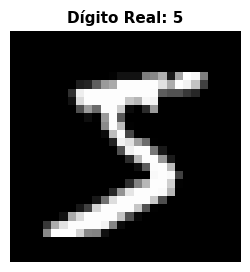

In [3]:
# Muestra la primera imagen del conjunto de entrenamiento como verificación visual
# del preprocesamiento aplicado en el bloque anterior.

# [0, :, :, 0]: primer índice selecciona la muestra, último índice descarta
# el eje de canal — imshow espera shape (alto, ancho), no (alto, ancho, 1).
imagen_ejemplo  = imagenes_entrenamiento[0, :, :, 0]
etiqueta_ejemplo = etiquetas_entrenamiento[0]

plt.figure(figsize=(3, 3))
# cmap='gray' es necesario; sin él matplotlib aplica su mapa de color por defecto
# (viridis) y la imagen aparece en tonos verdes/amarillos en lugar de blanco y negro.
plt.imshow(imagen_ejemplo, cmap='gray')
plt.title(f"Dígito Real: {etiqueta_ejemplo}", fontsize=11, fontweight="bold")
plt.axis('off')
plt.show()


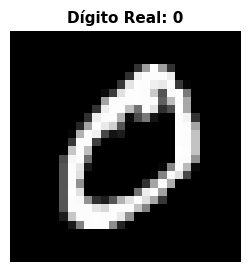

In [4]:
# Muestra la primera imagen del conjunto de entrenamiento como verificación visual
# del preprocesamiento aplicado en el bloque anterior.

# [0, :, :, 0]: primer índice selecciona la muestra, último índice descarta
# el eje de canal — imshow espera shape (alto, ancho), no (alto, ancho, 1).
imagen_ejemplo  = imagenes_entrenamiento[1, :, :, 0]
etiqueta_ejemplo = etiquetas_entrenamiento[1]

plt.figure(figsize=(3, 3))
# cmap='gray' es necesario; sin él matplotlib aplica su mapa de color por defecto
# (viridis) y la imagen aparece en tonos verdes/amarillos en lugar de blanco y negro.
plt.imshow(imagen_ejemplo, cmap='gray')
plt.title(f"Dígito Real: {etiqueta_ejemplo}", fontsize=11, fontweight="bold")
plt.axis('off')
plt.show()


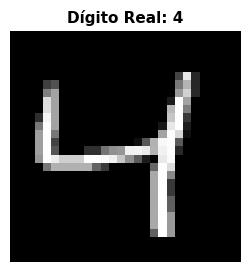

In [5]:
# Muestra la primera imagen del conjunto de entrenamiento como verificación visual
# del preprocesamiento aplicado en el bloque anterior.

# [0, :, :, 0]: primer índice selecciona la muestra, último índice descarta
# el eje de canal — imshow espera shape (alto, ancho), no (alto, ancho, 1).
imagen_ejemplo  = imagenes_entrenamiento[2, :, :, 0]
etiqueta_ejemplo = etiquetas_entrenamiento[2]

plt.figure(figsize=(3, 3))
# cmap='gray' es necesario; sin él matplotlib aplica su mapa de color por defecto
# (viridis) y la imagen aparece en tonos verdes/amarillos en lugar de blanco y negro.
plt.imshow(imagen_ejemplo, cmap='gray')
plt.title(f"Dígito Real: {etiqueta_ejemplo}", fontsize=11, fontweight="bold")
plt.axis('off')
plt.show()

## 2. Construcción y Entrenamiento de una CNN Simple

Diseñaremos una red convolucional secuencial pequeña para facilitar la inspección visual directa. Su arquitectura consta de:
1.  **Capa Convolucional (`Conv2D`):** Aplica filtros de $3 \times 3$ sobre los píxeles de entrada.
2.  **Capa de Agrupación (`MaxPooling2D`):** Submuestrea el espacio descartando activaciones secundarias.
3.  **Aplanado y Salida Densa:** Clasifica finalmente los mapas de características jerárquicos reducidos en probabilidades probabilísticas.

In [6]:
# CNN minimalista para MNIST, diseñada para demostrar visualización de filtros
# y mapas de activación. Intencionalmente sin capa Dense intermedia para mantener
# la arquitectura simple y fácil de inspeccionar.

modelo_cnn = tf.keras.Sequential([
    # input_shape solo se declara en la primera capa; Keras infiere el resto.
    # El segundo argumento 3 es equivalente a kernel_size=(3, 3).
    tf.keras.layers.Conv2D(16, 3, activation='relu', input_shape=(28, 28, 1)),

    # Sin argumentos usa el default pool_size=(2, 2), que reduce alto y ancho a la mitad.
    tf.keras.layers.MaxPooling2D(),

    # 32 filtros (doble que la capa anterior): capas más profundas requieren
    # mayor capacidad para representar combinaciones de patrones simples.
    tf.keras.layers.Conv2D(32, 3, activation='relu'),

    tf.keras.layers.Flatten(),

    # 10 neuronas = un score por dígito (0-9); softmax los convierte a probabilidades.
    tf.keras.layers.Dense(10, activation='softmax')
])


c:\Proyectos\rodriguez-carmen-pdi-1c-2026\venv312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
# Compila la CNN y la entrena en 3 épocas, suficiente para que los filtros
# aprendan patrones visibles sin necesidad de alcanzar precisión máxima.

modelo_cnn.compile(
    optimizer='adam',
    # sparse_categorical_crossentropy acepta etiquetas como enteros directamente,
    # sin necesidad de convertirlas a one-hot encoding.
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("✦ Iniciando el entrenamiento de la CNN por 3 épocas. Por favor, aguarden...")

modelo_cnn.fit(
    imagenes_entrenamiento,
    etiquetas_entrenamiento,
    epochs=3,
    # Reserva el último 10% del array de entrenamiento como validación (en orden,
    # sin mezclar), para monitorear sobreajuste sin tocar el conjunto de prueba.
    validation_split=0.1
)

print("\n✓ Entrenamiento completado.")


✦ Iniciando el entrenamiento de la CNN por 3 épocas. Por favor, aguarden...
Epoch 1/3
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9487 - loss: 0.1707 - val_accuracy: 0.9793 - val_loss: 0.0717
Epoch 2/3
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9826 - loss: 0.0562 - val_accuracy: 0.9873 - val_loss: 0.0466
Epoch 3/3
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9871 - loss: 0.0396 - val_accuracy: 0.9893 - val_loss: 0.0400

✓ Entrenamiento completado.


## 3. Visualización de Filtros Aprendidos (Kernels)

Los **filtros** son matrices pequeñas de coeficientes ajustables que la red convolucional aprende para extraer patrones de interés. Inspeccionaremos de forma directa la anatomía de los 16 filtros ajustados de la primera capa convolucional para observar qué tipo de bordes o esquinas detecta cada uno.

✓ Forma de los filtros aprendidos: (3, 3, 1, 16)


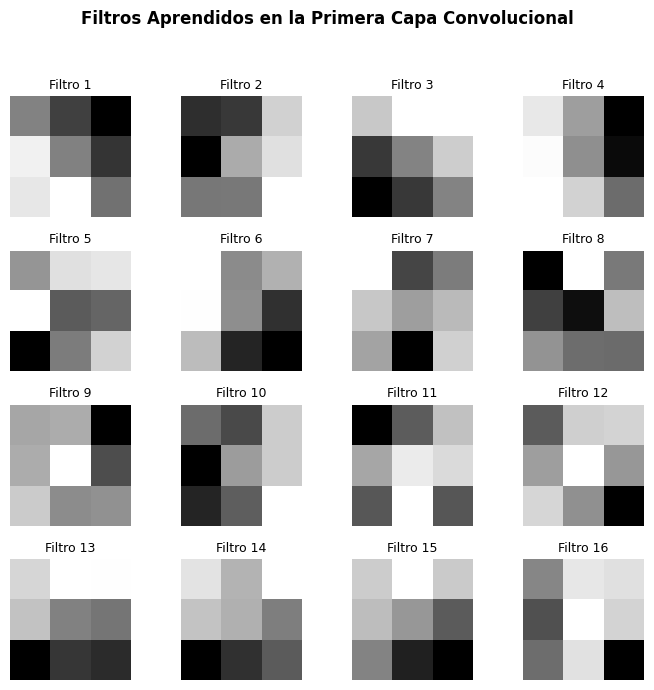

In [8]:
# Extrae los 16 filtros aprendidos de la primera capa Conv2D y los muestra
# en una grilla 4×4. Cada filtro es una matriz 3×3 que representa un detector
# de patrón (bordes, curvas, texturas) aprendido durante el entrenamiento.

# get_weights() devuelve [kernels, biases]; [0] toma solo los pesos del filtro.
primera_capa_pesos = modelo_cnn.layers[0].get_weights()
filtros_aprendidos = primera_capa_pesos[0]

# Shape resultante: (alto, ancho, canales_entrada, n_filtros) → (3, 3, 1, 16)
print(f"✓ Forma de los filtros aprendidos: {filtros_aprendidos.shape}")

# 4×4 = 16 subplots, uno por filtro (coincide con Conv2D(16, ...))
figura_filtros, ejes_filtros = plt.subplots(4, 4, figsize=(7, 7))
figura_filtros.suptitle('Filtros Aprendidos en la Primera Capa Convolucional', fontsize=12, fontweight="bold")

# ejes_filtros.flat convierte la matriz 4×4 de ejes en un iterador lineal
for i, ax in enumerate(ejes_filtros.flat):
    # [:, :, 0, i]: toda la ventana 3×3, canal 0 (único canal en escala de grises), filtro i
    matriz_filtro = filtros_aprendidos[:, :, 0, i]

    ax.imshow(matriz_filtro, cmap='gray')
    ax.set_title(f'Filtro {i+1}', fontsize=9)
    ax.axis('off')

# rect=[0,0,1,0.95] reserva el 5% superior para suptitle; sin esto el título se superpone.
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


## Consigna de Lectura e Interpretación

Observen la distribución de intensidades claras y oscuras en los filtros. ¿Pueden identificar algún filtro que parezca diseñado específicamente para detectar bordes estrictamente verticales u horizontalesi

Los filtros 7, 10 y 11 muestran una separación clara entre zonas superiores e inferiores, por lo que podrían responder a bordes horizontales. 

El filtro 8 presenta un cambio marcado de claro a oscuro de izquierda a derecha, compatible con la detección de bordes verticales. 

Sin embargo, estos filtros no fueron diseñados manualmente: sus valores fueron aprendidos durante el entrenamiento porque ayudaban a reducir el error de clasificación. 

Por eso no siempre tienen una estructura tan regular como los detectores clásicos de Sobel.

Otros filtros presentan distribuciones más irregulares y podrían detectar esquinas, diagonales o combinaciones de trazos.

## 4. Captura y Visualización de Mapas de Características

A medida que una imagen ingresa a la CNN, los filtros se convolucionan con ella generando **mapas de características**. Para inspeccionar estas respuestas espaciales en vivo, construiremos un modelo intermedio en Keras que capture las activaciones de las primeras dos capas.

In [9]:
# Variante más explícita del modelo interceptor: construye un grafo nuevo pasando
# un tensor de entrada fresco por las capas entrenadas, en lugar de reutilizar
# el tensor de entrada interno de modelo_cnn. Los pesos son los mismos en ambos casos.

# shape[1:] descarta la dimensión de lote (n_muestras) y conserva (alto, ancho, canales).
entrada = tf.keras.Input(
    shape=imagenes_prueba.shape[1:],
    name="imagen_entrada"
)

# Llamar a una capa como función sobre un tensor (API funcional) conecta esa capa
# al nuevo grafo reutilizando sus pesos ya entrenados, sin reinicializarlos.
salida_conv = modelo_cnn.layers[0](entrada)
salida_pool = modelo_cnn.layers[1](salida_conv)

modelo_activaciones = tf.keras.Model(
    inputs=entrada,
    outputs=[salida_conv, salida_pool]
)

# 0:1 preserva el eje de lote: shape (1, 28, 28, 1) en lugar de (28, 28, 1).
imagen_prueba_muestra   = imagenes_prueba[0:1]
etiqueta_prueba_muestra = etiquetas_prueba[0]

# predict con outputs=[conv, pool] devuelve una lista de dos arrays;
# el desempaquetado directo evita indexar activaciones[0] y activaciones[1].
activacion_conv, activacion_pool = modelo_activaciones.predict(
    imagen_prueba_muestra,
    verbose=0
)

print(f"Dígito real: {etiqueta_prueba_muestra}")
print("Convolución:", activacion_conv.shape)
print("Max-Pooling:", activacion_pool.shape)


Dígito real: 7
Convolución: (1, 26, 26, 16)
Max-Pooling: (1, 13, 13, 16)


## 4.1. Inspección de Mapas Convolucionales (`Conv2D`)

Graficaremos las 16 respuestas de salida producidas por la primera capa de convolución. Las zonas con mayor brillo (intensidad de color) delatan dónde reaccionó el filtro con mayor fuerza.

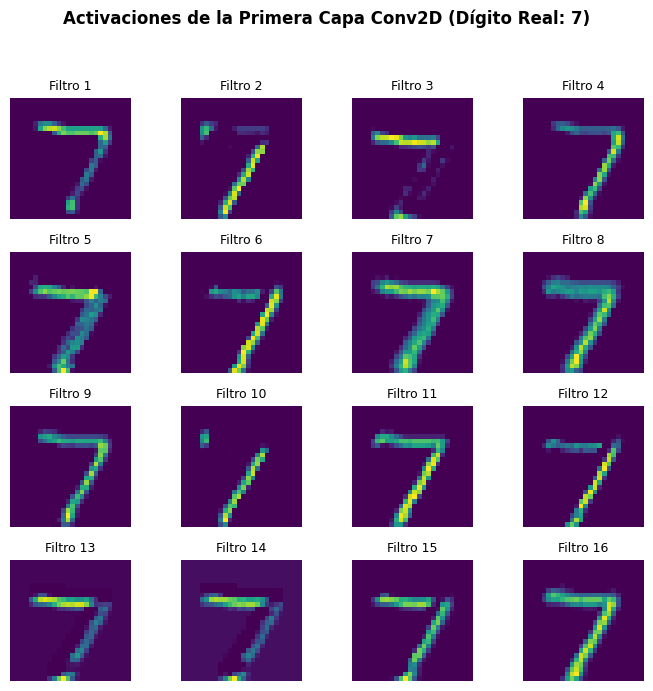

In [10]:
# Visualiza los 16 mapas de activación que produce la primera capa Conv2D al procesar
# la imagen de prueba: cada mapa muestra qué zonas activó cada filtro (zonas brillantes
# = alta respuesta al patrón que ese filtro detecta).
activaciones = modelo_activaciones.predict(
    imagen_prueba_muestra,
    verbose=0
)

# activaciones[0] es la salida de Conv2D; shape: (1, 26, 26, 16)
activacion_primera_capa = activaciones[0]
# shape[-1] da el número de filtros (último eje); no se usa en este bloque
# pero sirve como referencia si se generaliza la grilla a otra arquitectura.
num_filtros = activacion_primera_capa.shape[-1]

figura_conv, ejes_conv = plt.subplots(4, 4, figsize=(7, 7))
figura_conv.suptitle(f'Activaciones de la Primera Capa Conv2D (Dígito Real: {etiquetas_prueba[0]})', fontsize=12, fontweight="bold")

for i, ax in enumerate(ejes_conv.flat):
    # [0, :, :, i]: lote 0 (único elemento), todos los píxeles espaciales, filtro i
    mapa_caracteristicas = activacion_primera_capa[0, :, :, i]

    # viridis resalta mejor las diferencias de intensidad en activaciones que 'gray':
    # zonas de alta activación aparecen en amarillo, zonas inactivas en morado oscuro.
    ax.imshow(mapa_caracteristicas, cmap='viridis')
    ax.set_title(f'Filtro {i+1}', fontsize=9)
    ax.axis('off')

# rect=[0,0,1,0.95] reserva el 5% superior para suptitle y evita superposición.
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


## Consigna de Lectura e Interpretación

Observen con cuidado las activaciones convolucionales. ¿Por qué algunos filtros resaltan con nitidez el contorno izquierdo del dígito mientras que otros destacan el contorno superior o inferior?

Cada filtro aprendió una combinación distinta de pesos y, por lo tanto, responde a una orientación específica del cambio de intensidad:

- Los filtros con contraste de izquierda a derecha reaccionan a contornos verticales o laterales.
- Los que presentan contraste de arriba hacia abajo destacan bordes horizontales.
- Otros responden a diagonales, curvas o esquinas.

En la imagen:
- los filtros **2, 7, 8, 12 y 14** resaltan principalmente el trazo horizontal superior del número 7. 
- Los filtros **6 y 9** responden con mayor intensidad al trazo diagonal. 
- Otros, como el **3 y el 11**, destacan la esquina donde ambos trazos se unen. 
- El filtro 16 prácticamente no se activa porque el patrón que aprendió no está presente claramente en esta imagen.


En resumen: 
Los filtros resaltan diferentes contornos porque durante el entrenamiento cada uno aprendió pesos distintos y se especializó en determinados cambios locales de intensidad y orientación. Cuando una región del dígito coincide con el patrón de un filtro, la convolución produce una activación elevada y aparece brillante. La función ReLU elimina las respuestas negativas, dejando visibles solamente las coincidencias positivas. Así, algunos filtros detectan el borde superior, otros el lateral o diagonal y otros la unión entre trazos.

## 4.2. Inspección de Mapas Submuestreados (`MaxPooling2D`)

La capa de MaxPooling reduce a la mitad el tamaño del alto y ancho espacial de los mapas de características al retener únicamente el valor máximo de cada región local. Analizaremos cómo se preserva la información crítica bajo esta compresión espacial.

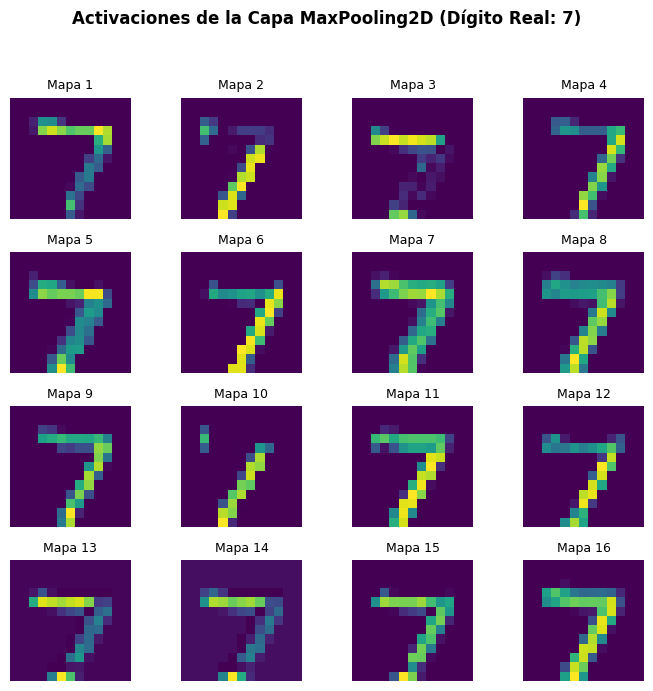

In [11]:
# Muestra las activaciones tras MaxPooling2D: los mismos 16 mapas que produjo Conv2D
# pero con resolución espacial reducida a la mitad (13×13 en lugar de 26×26).
# Permite comparar directamente qué información conserva y qué descarta el pooling.

# activaciones[1] es la salida de MaxPooling2D; shape: (1, 13, 13, 16)
activacion_segunda_capa = activaciones[1]

figura_pool, ejes_pool = plt.subplots(4, 4, figsize=(7, 7))
figura_pool.suptitle(f'Activaciones de la Capa MaxPooling2D (Dígito Real: {etiquetas_prueba[0]})', fontsize=12, fontweight="bold")

for i, ax in enumerate(ejes_pool.flat):
    mapa_submuestreado = activacion_segunda_capa[0, :, :, i]

    ax.imshow(mapa_submuestreado, cmap='viridis')
    ax.set_title(f'Mapa {i+1}', fontsize=9)
    ax.axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


## Consigna de Lectura e Interpretación

Comparen los mapas convolucionales (Conv2D) con los mapas de agrupación (MaxPooling). ¿Qué cambios observan en la resolución y nitidez de las imágenes comprimidasi ¿Por qué esta pérdida de resolución espacial resulta beneficiosa para la clasificación?

Los mapas de `Conv2D` tienen una resolución aproximada de `26 × 26`, mientras que después de aplicar `MaxPooling2D` se reducen a `13 × 13`. Esto ocurre porque el pooling toma bloques de `2 × 2` y conserva solamente el valor máximo de cada bloque.

En los mapas comprimidos se observa:

- Menor resolución y mayor pixelación.
- Pérdida de detalles pequeños y de la posición exacta de los bordes.
- Conservación de las activaciones más intensas.
- Los trazos principales del número 7 siguen siendo reconocibles.



Los mapas de Max-Pooling tienen aproximadamente la mitad de altura y anchura que los mapas convolucionales. Como resultado, las imágenes aparecen más pequeñas y pixeladas, y pierden detalles sobre la posición exacta de los contornos. Sin embargo, se conservan las activaciones más fuertes, que representan las características más importantes del dígito.

Esta pérdida de resolución resulta beneficiosa porque elimina información redundante y pequeñas variaciones que no son esenciales para clasificar la imagen. Además, reduce el coste computacional y la cantidad de parámetros de las capas posteriores, disminuye el riesgo de sobreajuste y hace que el modelo sea más robusto ante pequeños desplazamientos del dígito. La red necesita reconocer que la imagen contiene un “7”, no recordar la posición exacta de cada píxel.

## Conclusiones y Prácticas Sugeridas

Comprobaron visualmente cómo una CNN opera como un detector jerárquico de características espaciales locales. Los filtros se autoajustan para capturar rasgos primitivos (bordes y diagonales) y las capas de agrupación reducen la dimensionalidad física para proveer robustez e invarianza a traslaciones.

**Ejercicios de Experimentación Sugeridos:**
1. **Cambiar el Dígito de Entrada:** Seleccionen otro índice de prueba (por ejemplo `imagenes_prueba[5:6]`) y visualicen los cambios correspondientes en las activaciones convolucionales. ¿Qué filtros reaccionan con mayor potencia?
2. **Añadir Capas Convolucionales Profundas:** Extiendan la arquitectura con un bloque convolucional adicional (`Conv2D` y `MaxPooling`) y analicen cómo las activaciones en capas más profundas se tornan gradualmente abstractas y menos semejantes al dígito original.

In [12]:
# Variante más explícita del modelo interceptor: construye un grafo nuevo pasando
# un tensor de entrada fresco por las capas entrenadas, en lugar de reutilizar
# el tensor de entrada interno de modelo_cnn. Los pesos son los mismos en ambos casos.

# shape[1:] descarta la dimensión de lote (n_muestras) y conserva (alto, ancho, canales).
entrada = tf.keras.Input(
    shape=imagenes_prueba.shape[1:],
    name="imagen_entrada"
)

# Llamar a una capa como función sobre un tensor (API funcional) conecta esa capa
# al nuevo grafo reutilizando sus pesos ya entrenados, sin reinicializarlos.
salida_conv = modelo_cnn.layers[0](entrada)
salida_pool = modelo_cnn.layers[1](salida_conv)

modelo_activaciones = tf.keras.Model(
    inputs=entrada,
    outputs=[salida_conv, salida_pool]
)

# 0:1 preserva el eje de lote: shape (1, 28, 28, 1) en lugar de (28, 28, 1).
imagen_prueba_muestra   = imagenes_prueba[4:5]
etiqueta_prueba_muestra = etiquetas_prueba[4]

# predict con outputs=[conv, pool] devuelve una lista de dos arrays;
# el desempaquetado directo evita indexar activaciones[0] y activaciones[1].
activacion_conv, activacion_pool = modelo_activaciones.predict(
    imagen_prueba_muestra,
    verbose=0
)

print(f"Dígito real: {etiqueta_prueba_muestra}")
print("Convolución:", activacion_conv.shape)
print("Max-Pooling:", activacion_pool.shape)


Dígito real: 4
Convolución: (1, 26, 26, 16)
Max-Pooling: (1, 13, 13, 16)


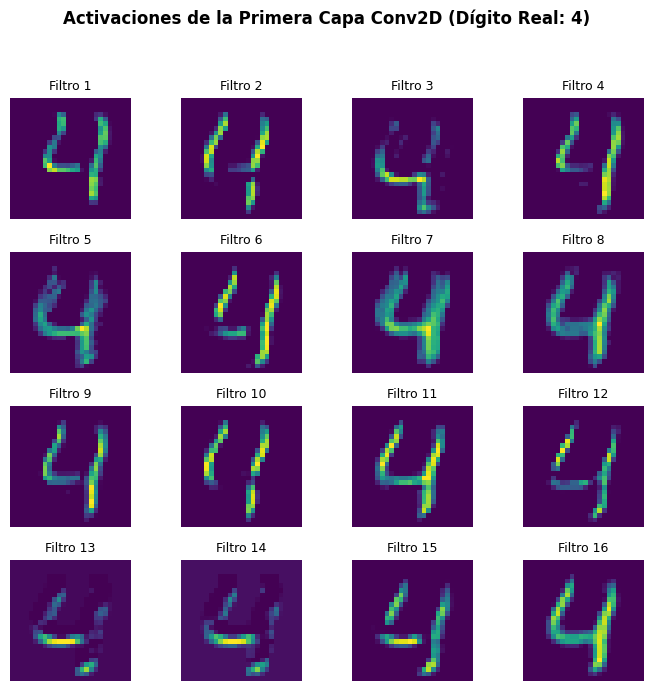

In [13]:
# Visualiza los 16 mapas de activación que produce la primera capa Conv2D al procesar
# la imagen de prueba: cada mapa muestra qué zonas activó cada filtro (zonas brillantes
# = alta respuesta al patrón que ese filtro detecta).
activaciones = modelo_activaciones.predict(
    imagen_prueba_muestra,
    verbose=0
)

# activaciones[0] es la salida de Conv2D; shape: (1, 26, 26, 16)
activacion_primera_capa = activaciones[0]
# shape[-1] da el número de filtros (último eje); no se usa en este bloque
# pero sirve como referencia si se generaliza la grilla a otra arquitectura.
num_filtros = activacion_primera_capa.shape[-1]

figura_conv, ejes_conv = plt.subplots(4, 4, figsize=(7, 7))
figura_conv.suptitle(f'Activaciones de la Primera Capa Conv2D (Dígito Real: {etiquetas_prueba[4]})', fontsize=12, fontweight="bold")

for i, ax in enumerate(ejes_conv.flat):
    # [0, :, :, i]: lote 0 (único elemento), todos los píxeles espaciales, filtro i
    mapa_caracteristicas = activacion_primera_capa[0, :, :, i]

    # viridis resalta mejor las diferencias de intensidad en activaciones que 'gray':
    # zonas de alta activación aparecen en amarillo, zonas inactivas en morado oscuro.
    ax.imshow(mapa_caracteristicas, cmap='viridis')
    ax.set_title(f'Filtro {i+1}', fontsize=9)
    ax.axis('off')

# rect=[0,0,1,0.95] reserva el 5% superior para suptitle y evita superposición.
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

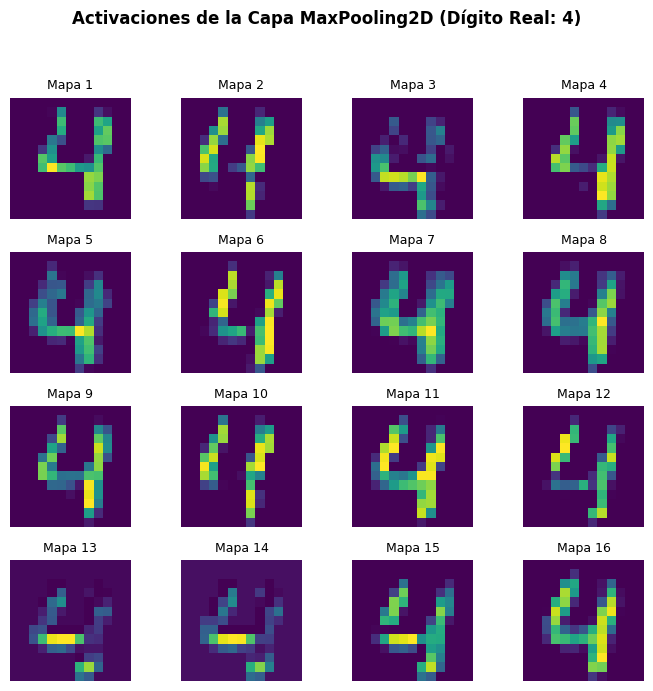

In [14]:
# Muestra las activaciones tras MaxPooling2D: los mismos 16 mapas que produjo Conv2D
# pero con resolución espacial reducida a la mitad (13×13 en lugar de 26×26).
# Permite comparar directamente qué información conserva y qué descarta el pooling.

# activaciones[1] es la salida de MaxPooling2D; shape: (1, 13, 13, 16)
activacion_segunda_capa = activaciones[1]

figura_pool, ejes_pool = plt.subplots(4, 4, figsize=(7, 7))
figura_pool.suptitle(f'Activaciones de la Capa MaxPooling2D (Dígito Real: {etiquetas_prueba[4]})', fontsize=12, fontweight="bold")

for i, ax in enumerate(ejes_pool.flat):
    mapa_submuestreado = activacion_segunda_capa[0, :, :, i]

    ax.imshow(mapa_submuestreado, cmap='viridis')
    ax.set_title(f'Mapa {i+1}', fontsize=9)
    ax.axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()